### Libraries Installation

In [1]:
# Basic Libraries Installation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Additional Libraries Installation
import sklearn, scipy, statsmodels, tensorflow
print("Libraries Installed Successfully")

Libraries Installed Successfully


### Steps to Understand the Data 

In [3]:
# Read the file
df = pd.read_excel("Online Retail.xlsx")

In [4]:
# Shows top 5 rows
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
# Shows total no. of rows & columns
df.shape

(541909, 8)

In [6]:
# Shows the name of all the columns
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


### Steps to check the common issues to be identified to clean the data

In [8]:
# Shows the total missing values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

*From the above output, the column <b>"Description"</b> has <b>1454</b> missing values and the column <b>"CustomerID"</b> has <b>135080</b> missing values.*

In [9]:
# Shows the duplicate rows
df.duplicated().sum()

np.int64(5268)

In [10]:
# Shows the basic stats of the data
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [11]:
# Check data types
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

### Cleaning Process of the Data

In [12]:
# Removes the missing values 
df = df.dropna(subset=["Description"])
df = df.dropna(subset=["CustomerID"])

##### *Removing the missing values instead of replacing it with mean or median <br>*

*<b>"CustomerID"</b> is an identifier, not a measurable value so, if we fill it with mean or median would create fake customers <br>*

*<b>"Description"</b> is categorical in nature so, replacing it with mean or median  could fill it with [Unknown] which adds noise and does not help with K-means clustering*

In [13]:
# Removes duplicate rows
df = df.drop_duplicates()

In [14]:
# Convert the data type of (CustomerID) from float to int
df["CustomerID"] = df["CustomerID"].astype(int)

In [15]:
# Review the total no. of rows and columns after removing missing values and duplicate rows
df.shape

(401604, 8)

In [16]:
# Re-check if there are any missing values
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [17]:
# Re-check if there are any duplicate rows
df.duplicated().sum()

np.int64(0)

In [18]:
# Re-check the datatypes
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
dtype: object

In [19]:
# Checks if dataset contains negative values in (Quantity)
df[df["Quantity"] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315,United Kingdom


In [20]:
# Dataset returns negative values in (Quantity)
# We have to remove it
df = df[df["Quantity"] >0]

In [21]:
# Check (UnitPrice) if it has any invalid prices
df[df["UnitPrice"] <=0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081,United Kingdom
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,0.0,15107,United Kingdom
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560,United Kingdom
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2011-03-23 10:25:00,0.0,13239,United Kingdom
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,2011-03-30 12:45:00,0.0,13113,United Kingdom
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,2011-04-04 14:42:00,0.0,14410,United Kingdom


In [22]:
# Removes the invalid prices
df = df[df["UnitPrice"] > 0]

### Feature Engineering

In [23]:
# Add a new column (TotalPrice)
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [24]:
# Re-check shape of the dataset to ensure if a new column has been added
df.shape

(392692, 9)

In [25]:
# Snapshot Date
snapshot_date = df["InvoiceDate"].max()

In [26]:
# Create an RFM (Recency, Frequency, Monetary)
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate" : "max",
    "InvoiceNo" : "nunique",
    "TotalPrice" : "sum"
})

In [27]:
# Rename the columns
rfm.columns = ["LastPurchase", "Frequency", "Monetary"]

In [28]:
# Create Recency separately
rfm["Recency"] = (snapshot_date - rfm["LastPurchase"]).dt.days

*Recency was created separately for easier understanding*

In [29]:
# Drop the helper column
rfm = rfm.drop(columns=["LastPurchase"])

In [30]:
rfm.head()

,Frequency,Monetary,Recency
CustomerID,,,
12346,1,77183.60,325
12347,7,4310.00,1
12348,4,1797.24,74
12349,1,1757.55,18
12350,1,334.40,309


In [31]:
# Basic Statistics Summary
rfm.describe()

,Frequency,Monetary,Recency
count,4338.000000,4338.000000,4338.000000
mean,4.272015,2048.688081,91.536422
std,7.697998,8985.230220,100.014169
min,1.000000,3.750000,0.000000
25%,1.000000,306.482500,17.000000
50%,2.000000,668.570000,50.000000
75%,5.000000,1660.597500,141.000000
max,209.000000,280206.020000,373.000000


### K-means Clustering

#### *Import Required Libraries*

In [32]:
# Import Libraries for Numerical and Data Manipulation
import numpy as np
import pandas as pd

# Import Libraries for Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# Import Machine Learning Libraries
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [34]:
# Configure the Visualization Aesthetics
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

#### *Verify the RFM Dataset*

In [35]:
# Display first few rows
rfm.head()

,Frequency,Monetary,Recency
CustomerID,,,
12346,1,77183.60,325
12347,7,4310.00,1
12348,4,1797.24,74
12349,1,1757.55,18
12350,1,334.40,309


In [36]:
# Check dataset information
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4338 entries, 12346 to 18287
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Frequency  4338 non-null   int64  
 1   Monetary   4338 non-null   float64
 2   Recency    4338 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 135.6 KB


In [37]:
# Basic Statistics Summary
rfm.describe()

,Frequency,Monetary,Recency
count,4338.000000,4338.000000,4338.000000
mean,4.272015,2048.688081,91.536422
std,7.697998,8985.230220,100.014169
min,1.000000,3.750000,0.000000
25%,1.000000,306.482500,17.000000
50%,2.000000,668.570000,50.000000
75%,5.000000,1660.597500,141.000000
max,209.000000,280206.020000,373.000000


In [38]:
# Ensure there are no missing values
rfm.isnull().sum()

Frequency    0
Monetary     0
Recency      0
dtype: int64

#### *Standard Scaling*

In [39]:
# Initialize the Standard Scaler
scaler = StandardScaler()

# Fit and Transform the data
rfm_scaled = scaler.fit_transform(rfm)

In [40]:
# Convert from Series to DataFrame
rfm_scaled = pd.DataFrame(rfm_scaled,
                          columns=rfm.columns,
                          index=rfm.index)
# Display the scaled data
rfm_scaled.head()

,Frequency,Monetary,Recency
CustomerID,,,
12346,-0.425097,8.363010,2.334574
12347,0.354417,0.251699,-0.905340
12348,-0.035340,-0.027988,-0.175360
12349,-0.425097,-0.032406,-0.735345
12350,-0.425097,-0.190812,2.174578


In [41]:
# Verify whether scaled data has mean is 0 and std is 1
rfm_scaled.describe().round(2)

,Frequency,Monetary,Recency
count,4338.00,4338.00,4338.00
mean,0.00,0.00,0.00
std,1.00,1.00,1.00
min,-0.43,-0.23,-0.92
25%,-0.43,-0.19,-0.75
50%,-0.30,-0.15,-0.42
75%,0.09,-0.04,0.49
max,26.60,30.96,2.81


#### *Determine the Optimal Number of Clusters (Elbow Method)*

In [42]:
# Initialize an empty list to store WCSS values
wcss = []

# Define the range for possible cluster values
cluster_range = range(1,11)

# Compute WCSS for each value of k
for k in cluster_range:
    kmeans = KMeans(
        n_clusters = k,
        init = "k-means++",
        random_state = 42,
        n_init = 10
    )
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

# Display WCSS Values
wcss

[13014.000000000004,
 9014.566279572977,
 5441.3235868296615,
 4096.300210662247,
 3119.7898598001516,
 2473.7933635647614,
 2023.586627223549,
 1717.0110430839186,
 1468.7871021842977,
 1281.0480511013266]

#### *Plot the Elbow Curve - Visualization*

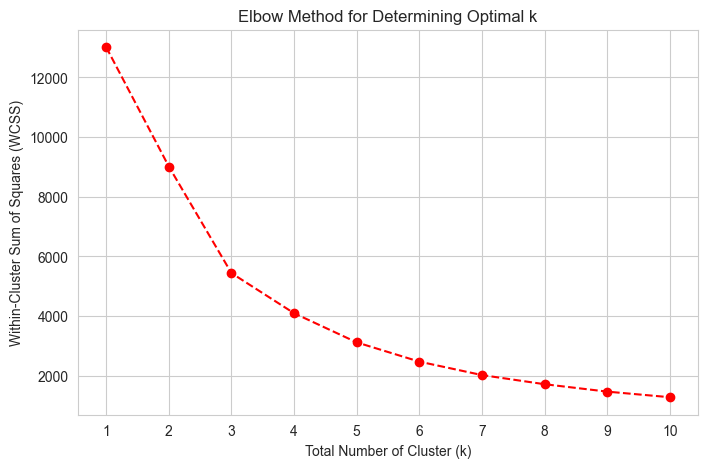

In [56]:
# Plot the Elbow Method Graph
plt.figure()
plt.plot(cluster_range, wcss, marker="o", linestyle="--", color="red")
plt.title("Elbow Method for Determining Optimal k")
plt.xlabel("Total Number of Cluster (k)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.xticks(cluster_range)
plt.savefig("outputs/elbow_method.png", dpi=300)
plt.show()

#### *Apply K-Means Clustering*

In [44]:
# Set optimal number of cluster
optimal_k = 4

# Initialize the KMeans Model
kmeans = KMeans(
    n_clusters = optimal_k,
    init = "k-means++",
    random_state = 42,
    n_init = 10
)

# Fit the model and predict clusters
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

# Display the clustered dataset
rfm.head()

,Frequency,Monetary,Recency,Cluster
CustomerID,,,,
12346,1,77183.60,325,3
12347,7,4310.00,1,0
12348,4,1797.24,74,0
12349,1,1757.55,18,0
12350,1,334.40,309,1


#### *Analyze the Clusters*

In [45]:
# Count total no. of customers in each cluster
rfm["Cluster"].value_counts().sort_index()

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

In [46]:
# Calculate average RFM values per cluster
cluster_summary = rfm.groupby("Cluster").agg({
    "Recency" : "mean",
    "Frequency" : "mean",
    "Monetary" : "mean"
}).round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,42.70,3.68,1353.63
1,247.08,1.55,478.85
2,6.38,82.54,127187.96
3,14.50,22.33,12690.50


#### *Visualize Customer Segments*

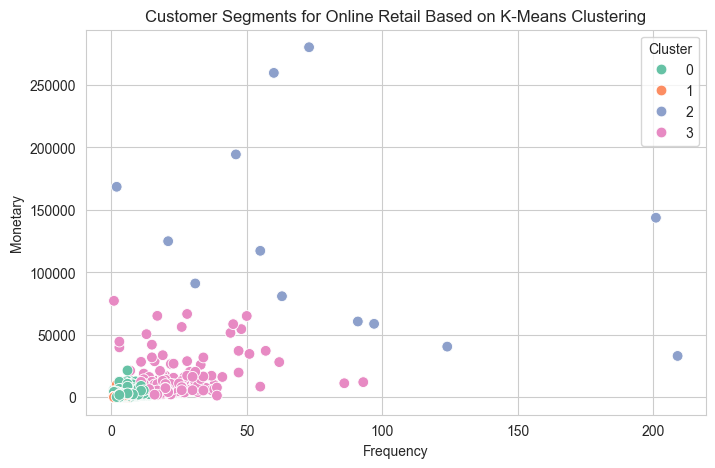

In [57]:
# Scatter Plot - Frequency vs Monetary

plt.figure()
sns.scatterplot(
    data = rfm,
    x = "Frequency",
    y = "Monetary",
    hue = "Cluster",
    palette = "Set2",
    s = 60
)

plt.title("Customer Segments for Online Retail Based on K-Means Clustering")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.legend(title = "Cluster")
plt.savefig("outputs/frequency_vs_monetary.png", dpi=300)
plt.show()

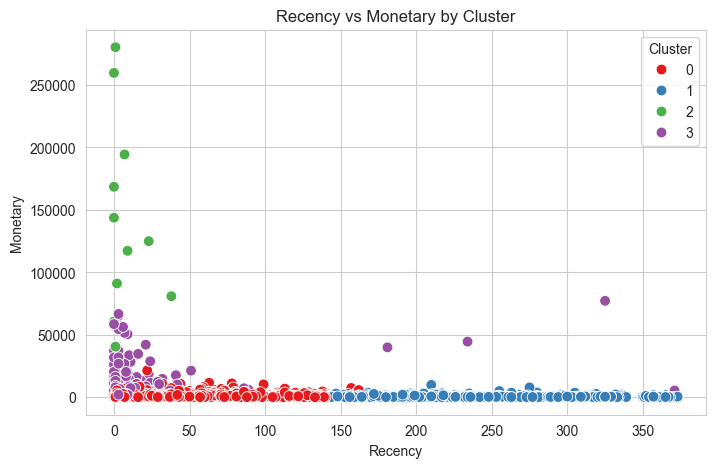

In [58]:
# Scatter Plot - Recency vs Monetary

plt.figure()
sns.scatterplot(
    data = rfm,
    x = "Recency",
    y = "Monetary",
    hue = "Cluster",
    palette = "Set1",
    s = 60
)

plt.title("Recency vs Monetary by Cluster")
plt.savefig("outputs/recency_vs_monetary.png", dpi=300)
plt.show()

#### *Label Customer Segments*

In [49]:
# Display cluster means for interpretation
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,42.70,3.68,1353.63
1,247.08,1.55,478.85
2,6.38,82.54,127187.96
3,14.50,22.33,12690.50


In [50]:
# Define names for each segment
segment_labels = {
    0 : "Loyal Customers",
    1 : "At-Risk Customers",
    2 : "Big Spenders",
    3 : "New Customers"
}

rfm["Segment"] = rfm["Cluster"].map(segment_labels)

# Display the updated dataset
rfm.head()

,Frequency,Monetary,Recency,Cluster,Segment
CustomerID,,,,,
12346,1,77183.60,325,3,New Customers
12347,7,4310.00,1,0,Loyal Customers
12348,4,1797.24,74,0,Loyal Customers
12349,1,1757.55,18,0,Loyal Customers
12350,1,334.40,309,1,At-Risk Customers


In [51]:
# Count total no. of customers in each segment
rfm["Segment"].value_counts()

Segment
Loyal Customers      3054
At-Risk Customers    1067
New Customers         204
Big Spenders           13
Name: count, dtype: int64

#### *Visualize Segment Distribution*

In [54]:
import os
os.makedirs("outputs", exist_ok=True)
print("Output folder is ready!")

Output folder is ready!


C:\Users\dearm\AppData\Local\Temp\ipykernel_10776\386975376.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


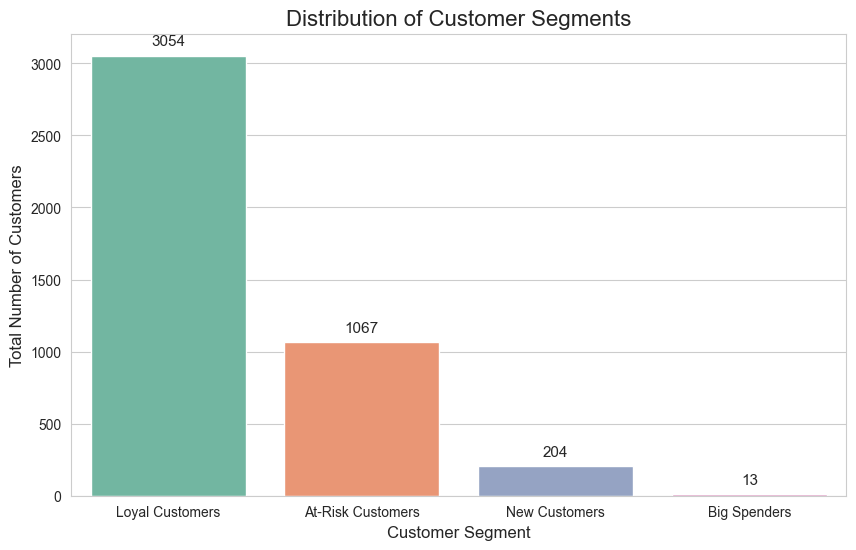

In [55]:
# figsize determines the width and height of the plot
plt.figure(figsize = (10,6))
# Visualizes the no. of customers in each segment
ax = sns.countplot(
    data = rfm, 
    x = "Segment", 
    palette = "Set2",
    order = rfm["Segment"].value_counts().index
)
# Add Titles and Labels
plt.title("Distribution of Customer Segments", fontsize=16)
plt.xlabel("Customer Segment", fontsize=12)
plt.ylabel("Total Number of Customers", fontsize=12)

# Add Value Labels on bars (Exact no. of customers in each segment)
for bar in ax.patches:
    # Get the height of each bar
    bar_height = bar.get_height()
    # Get the center position of each bar
    bar_x_position = bar.get_x() + bar.get_width() / 2
    # Add annotation
    ax.annotate(
    text = f'{int(bar_height)}',
    xy = (bar_x_position, bar_height),
    xytext = (0,5),
    textcoords = "offset points",
    ha = "center",
    va = "bottom",
    fontsize=11
)
plt.savefig("outputs/customer_segment_distribution.png", dpi=300)
plt.show()